In [40]:
import numpy as np
import pandas as pd
import sys
import os
import glob
import matplotlib.pyplot as plt
from brokenaxes import brokenaxes
cwd = os.getcwd()
root = cwd.split("BernsteinMartingaleNet")[0] + "BernsteinMartingaleNet"
if root not in sys.path:
    sys.path.append(root)

In [41]:
def add_bar(name, path):
    df = pd.read_csv(path + "/final_losses.csv")
    values.append(df.iloc[2]["loss"])
    names.append(name)
    return values


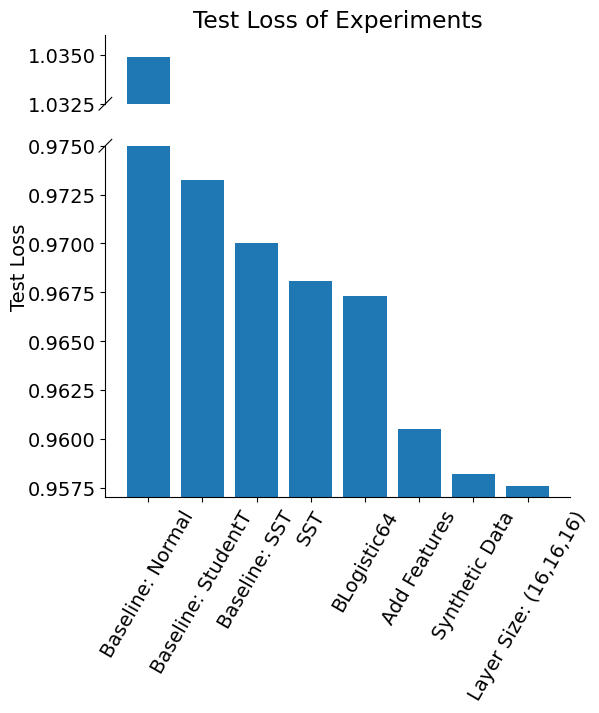

In [42]:
names = []
values = []
add_bar("Baseline: Normal", root + "/Results/DistCompare/Normal")
add_bar("Baseline: StudentT", root + "/Results/DistCompare/StudentT")
add_bar("Baseline: SST", root + "/Results/DistCompare/SkewedStudentT")
add_bar("SST", root + "/Results/AdjustDistCompare/SkewedStudentT")
add_bar("BLogistic64", root + "/Results/AdjustDistCompare/BLogistic64")
add_bar("Add Features", root + "/Results/BLogistic64FullFeature")
add_bar("Synthetic Data", root + "/Results/BLogistic64FullFeatureSynthetic")
add_bar("Layer Size: (16,16,16)", root + "/Results/BLogistic64Layers16-16-16")

plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(6, 6))
bax = brokenaxes(ylims=((0.957, 0.975), (1.0325, 1.036)))
bax.bar(names,values)
#bax.set_xticks(range(len(names)))
bottom_ax = bax.axs[-1]           # bottom subplot that actually shows the x-axis
bottom_ax.set_xticks(names)
bottom_ax.set_xticklabels(names, rotation=60, ha="center")

#out = bax.set_xticklabels(names, rotation=60)
bax.set_ylabel("Test Loss", labelpad=55)
_ = bax.set_title("Test Loss of Experiments")
plt.savefig("test_loss.eps")